In [1]:
from abc import ABC
from abc import abstractmethod
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import random


Data generation copied from sci-kit example [here](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_assumptions.html#sphx-glr-auto-examples-cluster-plot-kmeans-assumptions-py)


In [2]:
from sklearn.datasets import make_blobs
n_samples = 1500
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X, y = make_blobs(n_samples=n_samples, random_state=random_state)
X_aniso = np.dot(X, transformation)  # Anisotropic blobs
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)  # Unequal variance
X_filtered = np.vstack(
    (X[y == 0][:500], X[y == 1][:100], X[y == 2][:10])
)  # Unevenly sized blobs
y_filtered = [0] * 500 + [1] * 100 + [2] * 10

def plot_four_clusters(title, y_gaussian, y_anisotropical, y_varied, y_filtered):
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
    
    axs[0, 0].scatter(X[:, 0], X[:, 1], c=y_gaussian)
    axs[0, 0].set_title("Mixture of Gaussian Blobs")
    
    axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_anisotropical)
    axs[0, 1].set_title("Anisotropically Distributed Blobs")
    
    axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
    axs[1, 0].set_title("Unequal Variance")
    
    axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
    axs[1, 1].set_title("Unevenly Sized Blobs")
    
    plt.suptitle(title).set_y(0.95)
    plt.show()

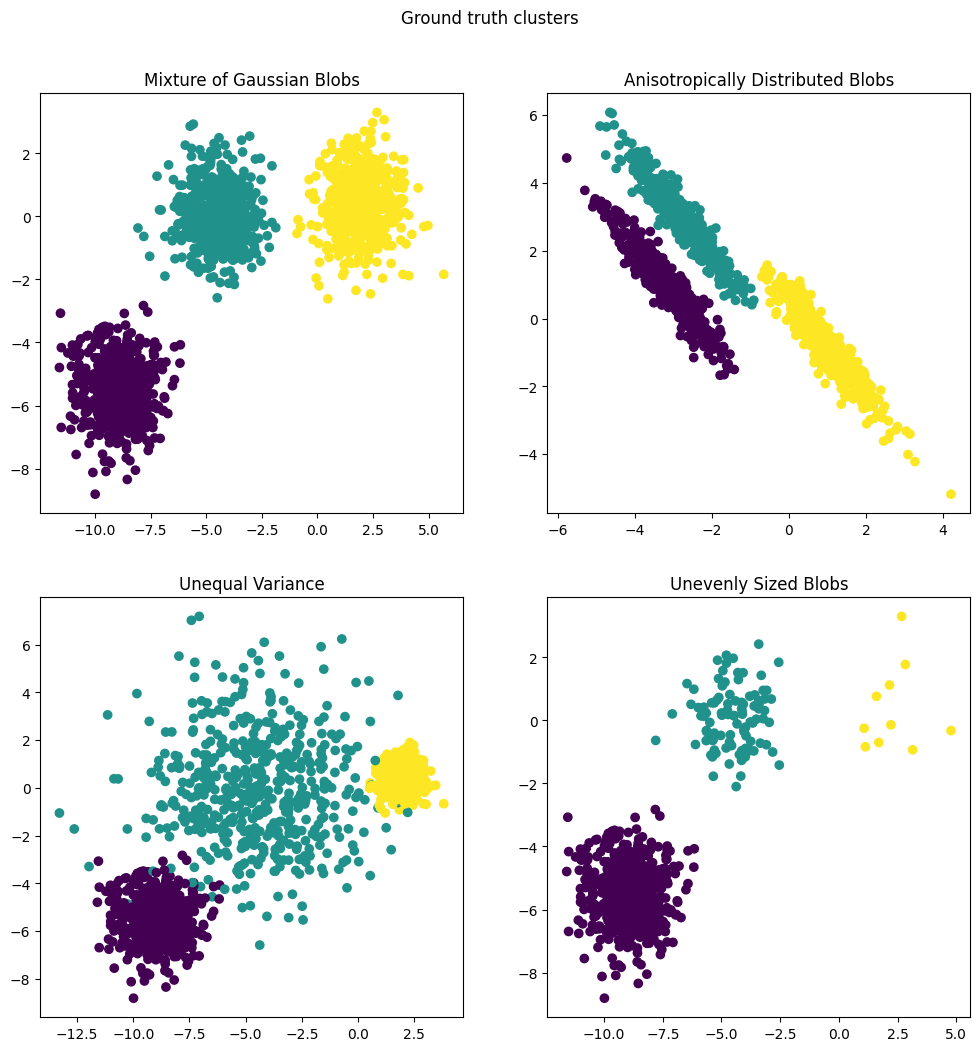

In [3]:
plot_four_clusters("Ground truth clusters", y,y, y_varied, y_filtered)

In [4]:
class KMeansBase(ABC):
    def __init__(self, num_clusters:int, 
                 random_seed:float=170, 
                 max_iterations:int=300, 
                 exit_tolerance:float=1e-4,
                default_n_inits:int=10):
        self.num_clusters = num_clusters
        self.random_seed = random_seed
        self.max_number_iterations = max_iterations
        self.exit_tolerance = exit_tolerance
        self.default_n_inits = default_n_inits
        self._cluster_centres = None # array of shape (n_clusters, n_features)
        self._last_predicts_cluster_squared_distances = None

    @abstractmethod
    def fit(self, X):
        # X shape (n_samples, n_features)
        pass

    def predict(self, X:np.ndarray) -> np.ndarray:
        # X shape (n_samples, n_features).
        # Returns labels array of shape (n_samples,).
        if self._cluster_centres is None:
            raise ValueError("No cluster centres found, fit probably not run")

        # self._cluster_centres; array of shape (n_clusters, n_features)
        
        # Assign cluster_id for each value of X, based on proximity to Kth cluster
        # Find euclidean distance between X and each cluster feature
        # probably best to store this in array -> n_samples, kth_cluser_distance
        # Can then return argmin across the rows to get the labels.

        # Loop over each row of X, compute distances, append to new array, for now.
        # Distance defined as (p1-p2)^2
        # labels = None
        # for x_row in X:
        #     distances = ((x_row - self._cluster_centres)**2).sum(axis=1) # will be (n_clusters,)
        #     # import pdb; pdb.set_trace()
        #     if labels is None:
        #         labels = np.argmin(distances, axis=0)
        #     else: 
        #         labels = np.vstack((labels, np.argmin(distances, axis=0)))

        # Should be faster than the for-loop
        def get_min_dist(x_row):
            sq_dist = ((x_row - self._cluster_centres)**2).sum(axis=1)
            min_id = np.argmin(sq_dist)
            return min_id, sq_dist[min_id]
        # get_min_dist_id = lambda x_row: np.argmin(((x_row - self._cluster_centres)**2).sum(axis=1))
        labels = np.apply_along_axis(get_min_dist,1,X)
        self._last_predicts_cluster_squared_distances = labels[:,1]

        # if len(np.unique(labels[:,0])) != self.num_clusters :
        #     print(f'Expected {self.num_clusters} clusters, got {np.unique(labels[:,0])}')
        #     import pdb; pdb.set_trace()
        return labels[:,0]
        

In [5]:
class SklearnKMeans(KMeansBase):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.kmean = KMeans(self.num_clusters, init='random', random_state=self.random_seed)

    def fit(self, X):
        self.kmean.fit(X)
        self._cluster_centres = self.kmean.cluster_centers_

sk_kmean = SklearnKMeans(3)
sk_kmean.fit(X)
for x_variant in [X, X_aniso, X_filtered, X_varied]:
    sk_kmean.fit(x_variant)
    sk_preds = sk_kmean.kmean.predict(x_variant)
    my_preds = sk_kmean.predict(x_variant)
    assert sk_preds.shape == my_preds.shape, f'sk_preds shape {sk_preds.shape} != my_preds shape {my_preds.shape}'
    assert np.array_equal(sk_preds, my_preds)

Timing tests, the predict implemented here is much slower, but is in python

In [6]:
%%timeit
sk_kmean.predict(X)

8.36 ms ± 28.7 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [7]:
%%timeit
sk_kmean.kmean.predict(X)

214 µs ± 4.09 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


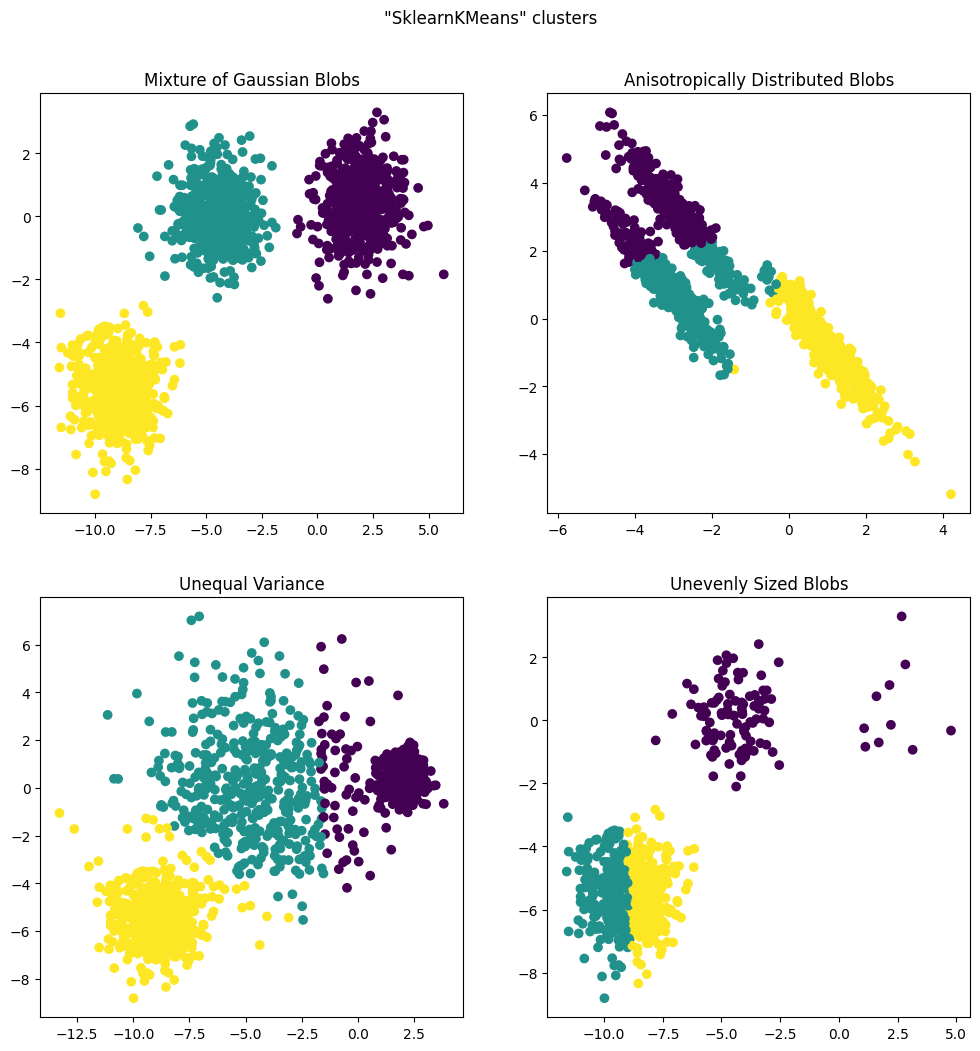

In [8]:

def run_kmeans(KMeans_Class:KMeansBase, 
               plot=True, X_gaussian=X, X_aniso=X_aniso, X_filtered=X_filtered, X_varied=X_varied
              ) -> list[np.ndarray]:
    kmeans = KMeans_Class(3)
    preds = []
    for x_variant in [X, X_aniso, X_varied, X_filtered]:
        kmeans.fit(x_variant)
        preds.append(kmeans.predict(x_variant))
    # import pdb; pdb.set_trace()
    if plot:
        plot_four_clusters(f'"{KMeans_Class.__name__}" clusters', *preds)
    return preds

preds = run_kmeans(SklearnKMeans, plot=True)

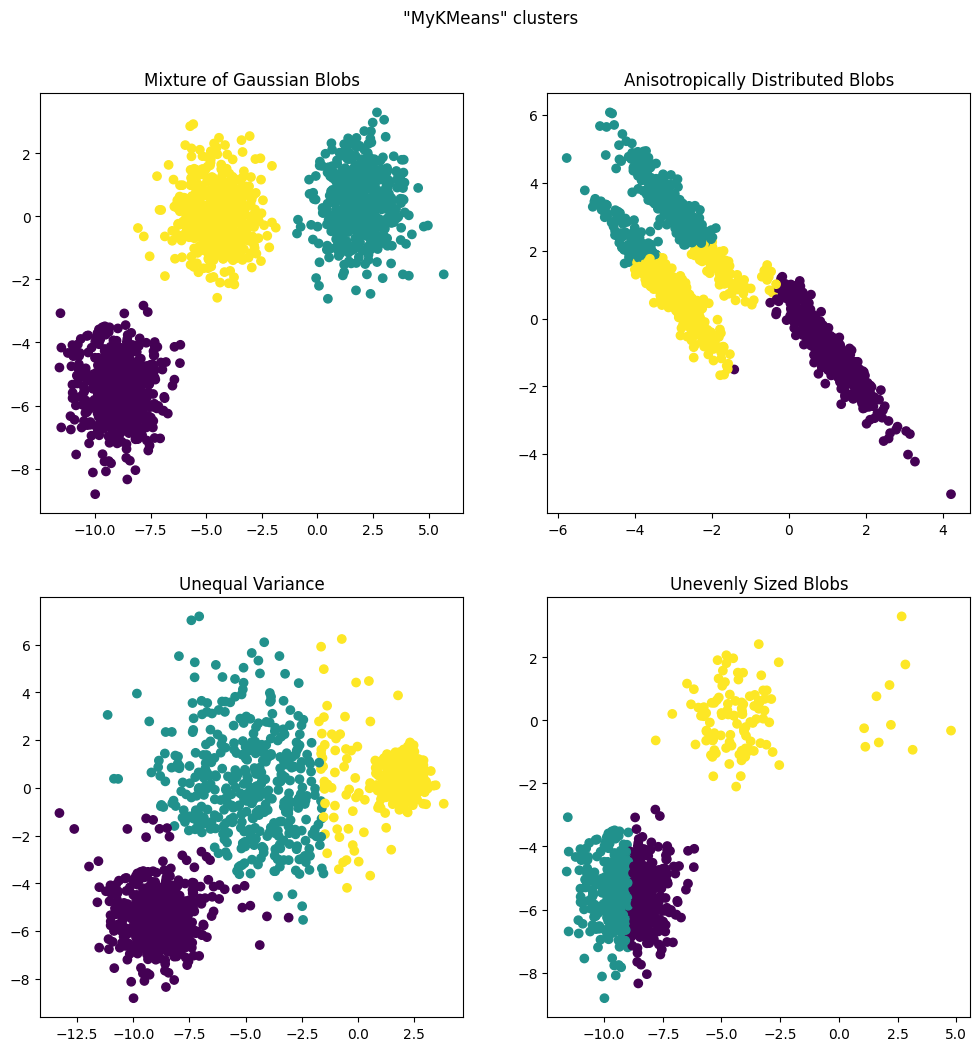

In [9]:
class MyKMeans(KMeansBase):

    def __create_initial_cluster(self, Xdata, number_of_clusters:int) -> np.ndarray:
        # r_ids = np.random.randint(0, Xdata.shape[0],size=number_of_clusters)
        r_ids = random.sample(list(range(Xdata.shape[0])), number_of_clusters)
        return Xdata[r_ids,:] # new cluster

    def __adjust_cluster_means(self, Xdata):
        for epoch in range(self.max_number_iterations):
            predictions = self.predict(Xdata)
            old_cluster_norm = np.linalg.norm(self._cluster_centres)
            for cluster_id in range(self.num_clusters):
                cluster_points = Xdata[np.where(predictions==cluster_id)[0],:]
                if cluster_points.size < 0 or np.any(np.isnan(cluster_points)):
                    print(f'Bad cluster points, for {self._cluster_centres[cluster_id]}\n{cluster_points}')
                    raise ValueError()
                self._cluster_centres[cluster_id] = cluster_points.mean(axis=0)
            cluster_distances = np.linalg.norm(self._cluster_centres) - old_cluster_norm
            if cluster_distances < self.exit_tolerance:
                # print(f'Exit criteria reached, exiting at {epoch}')
                break

    def fit(self, X):
        min_inertia = None
        best_clusters = None
        for kmean_init_id in range(self.default_n_inits):
            self._cluster_centres = self.__create_initial_cluster(X, self.num_clusters)
            self.__adjust_cluster_means(X)
            
            inertia = self._last_predicts_cluster_squared_distances.sum()
            if min_inertia is None:
                min_inertia = inertia
                best_clusters = np.copy(self._cluster_centres)
            elif inertia < min_inertia:
                min_inertia = inertia
                best_clusters = np.copy(self._cluster_centres)
        self._cluster_centres = best_clusters

preds = run_kmeans(MyKMeans, plot=True)

In [10]:
%%timeit
# m_kmean = MyKMeans(3)
# m_kmean.fit(X)
preds = run_kmeans(MyKMeans, plot=False)

1.03 s ± 98.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [11]:
%%timeit
preds = run_kmeans(SklearnKMeans, plot=False)


121 ms ± 1.69 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
